In [2]:
import os

train_cats = "../data/raw/training_set/training_set/cats"
train_dogs = "../data/raw/training_set/training_set/dogs"

test_cats = "../data/raw/test_set/test_set/cats"
test_dogs = "../data/raw/test_set/test_set/dogs"

print("Training Cats:", len(os.listdir(train_cats)))
print("Training Dogs:", len(os.listdir(train_dogs)))

print("Test Cats:", len(os.listdir(test_cats)))
print("Test Dogs:", len(os.listdir(test_dogs)))

Training Cats: 4001
Training Dogs: 4006
Test Cats: 1012
Test Dogs: 1013


In [3]:
import os

print(os.getcwd())

/Users/tanishqbakshi/CNN_PROJECT/notebooks


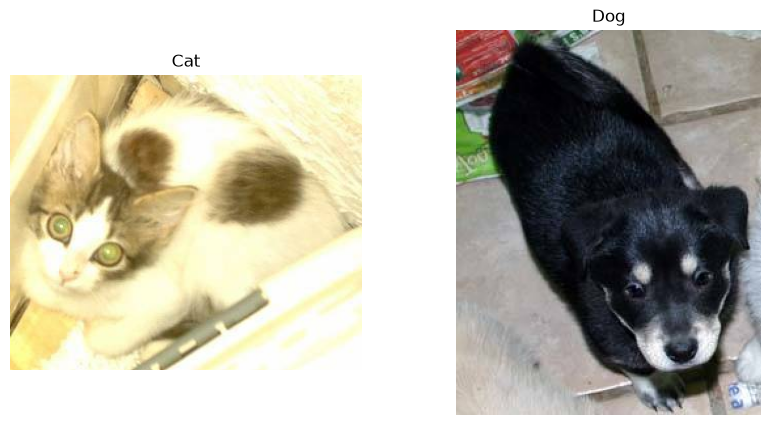

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

cat_folder = "../data/raw/training_set/training_set/cats"
dog_folder = "../data/raw/training_set/training_set/dogs"

cat_img = random.choice(os.listdir(cat_folder))
dog_img = random.choice(os.listdir(dog_folder))

cat_path = os.path.join(cat_folder, cat_img)
dog_path = os.path.join(dog_folder, dog_img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(Image.open(cat_path))
plt.title("Cat")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Image.open(dog_path))
plt.title("Dog")
plt.axis("off")

plt.show()

In [5]:
from PIL import Image
import os
import random

sample_images = []

sample_images.append(
    os.path.join(cat_folder, random.choice(os.listdir(cat_folder)))
)

sample_images.append(
    os.path.join(dog_folder, random.choice(os.listdir(dog_folder)))
)

for img_path in sample_images:
    img = Image.open(img_path)
    print(os.path.basename(img_path))
    print("Size:", img.size)
    print("Mode:", img.mode)
    print("-"*30)

cat.1111.jpg
Size: (499, 375)
Mode: RGB
------------------------------
dog.1488.jpg
Size: (500, 374)
Mode: RGB
------------------------------


In [6]:
import pandas as pd

summary = pd.DataFrame({
    "Class": ["Cat", "Dog"],
    "Training Images": [4001, 4006],
    "Test Images": [1012, 1013]
})

summary

,Class,Training Images,Test Images
0,Cat,4001,1012
1,Dog,4006,1013


In [1]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "../data/raw/training_set/training_set"
test_dir = "../data/raw/test_set/test_set"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_ds.class_names)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Found 2023 files belonging to 2 classes.
Classes: ['cats', 'dogs']


In [2]:
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [3]:
dataset_iterator = iter(train_ds)

images, labels = next(dataset_iterator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


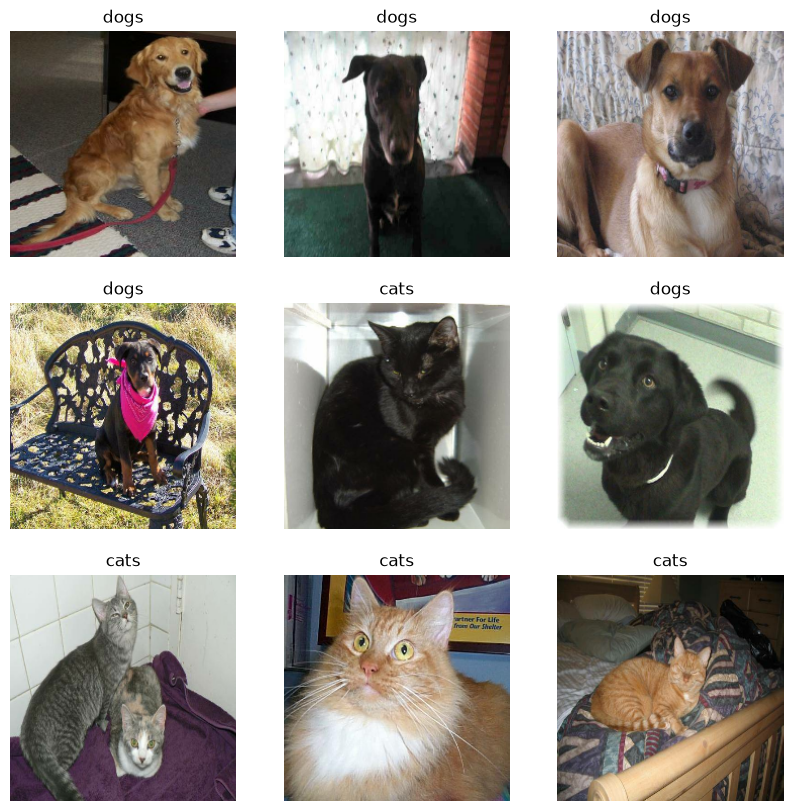

In [4]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names

plt.figure(figsize=(10,10))

images, labels = next(iter(train_ds))

for i in range(9):
    ax = plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))

    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [6]:
from tensorflow.keras import layers
from tensorflow.keras import models

cnn_model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(224,224,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

cnn_model.summary()

/Users/tanishqbakshi/CNN_PROJECT/.venv/lib/python3.13/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 187s 925ms/step - accuracy: 0.5928 - loss: 0.6668 - val_accuracy: 0.6771 - val_loss: 0.5895
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 189s 942ms/step - accuracy: 0.7011 - loss: 0.5695 - val_accuracy: 0.7258 - val_loss: 0.5442
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 181s 899ms/step - accuracy: 0.7572 - loss: 0.4972 - val_accuracy: 0.7495 - val_loss: 0.5291
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 179s 892ms/step - accuracy: 0.8101 - loss: 0.4063 - val_accuracy: 0.7395 - val_loss: 0.6153
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 179s 892ms/step - accuracy: 0.8529 - loss: 0.3413 - val_accuracy: 0.7626 - val_loss: 0.5933
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 184s 918ms/step - accuracy: 0.8944 - loss: 0.2482 - val_accuracy: 0.7608 - val_loss: 0.6916
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 180s 894ms/step - accuracy: 0.9263 - loss: 0.1742 - val_accuracy: 0.7651 - val_loss: 0.7732
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 181s 898ms/step - accuracy: 0.9411 -

# Baseline CNN

Input Size: 224x224x3

Architecture:
- Conv2D (32)
- MaxPooling
- Conv2D (64)
- MaxPooling
- Conv2D (128)
- MaxPooling
- Flatten
- Dense (128)
- Dropout (0.5)
- Dense (1)

Optimizer: Adam
Loss Function: Binary Crossentropy
Metric: Accuracy
Epochs: 10

In [10]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 231ms/step - accuracy: 0.7474 - loss: 1.0416
Test Accuracy: 0.7474048733711243
Test Loss: 1.041638731956482


In [11]:
cnn_model.save("../models/cnn_model.keras")

## Baseline CNN Results

Training Accuracy: 96.7%

Validation Accuracy: 76.7%

Test Accuracy: 74.7%

Observation:
The model shows significant overfitting.